# Social Media Addiction vs Productivity  
## Result Analysis Handoff Notebook

**Main tasks covered**
- Regression analysis: predicting `productivity_score`
- Classification analysis: predicting `addiction_level`
- Feature importance interpretation
- PPT and final submission checklist

# 1. Project Overview

The project uses the **Social Media Addiction vs Productivity Dataset** to analyze how social media usage is related to productivity and addiction level.

The project has two main machine learning tasks:

1. **Regression Task**  
   Predict `productivity_score`, which is a numerical target variable.

2. **Classification Task**  
   Predict `addiction_level`, which has three classes: `Low`, `Medium`, and `High`.

The result analysis focuses on comparing model performances and explaining what the results mean in relation to the project objective.


# 2. Dataset Summary

The dataset contains behavioral, lifestyle, and digital activity features.

| Feature | Description |
|---|---|
| `age` | Age of the individual |
| `daily_screen_time` | Total daily screen time |
| `social_media_hours` | Daily social media usage time |
| `study_hours` | Daily study or productive work time |
| `sleep_hours` | Daily sleep duration |
| `notifications_per_day` | Number of notifications per day |
| `focus_score` | Focus level score |
| `addiction_level` | Addiction level: Low, Medium, High |
| `productivity_score` | Productivity score from 0 to 100 |

The original project proposal describes the dataset as having about **6000 rows and 9 columns**, with missing values in the dataset.  
For modeling, missing values were handled before training the models.


# 3. Key EDA Findings Used for Interpretation

The model results should be interpreted together with the EDA findings.

Key findings from EDA:

- `social_media_hours` and `daily_screen_time` showed a negative relationship with `productivity_score`.
- `study_hours` showed a positive relationship with `productivity_score`.
- Higher `addiction_level` was related to higher `social_media_hours` and `daily_screen_time`.
- Higher `addiction_level` was also related to lower `productivity_score` and lower `focus_score`.

These findings support the main project idea: social media usage is related to productivity and addiction level.


# 4. Regression Result Analysis

## 4.1 Objective

The regression task predicts `productivity_score` using behavioral and lifestyle features.

The models were evaluated using:

- **RMSE**: Lower is better. It shows the average prediction error.
- **R² Score**: Higher is better. It shows how much of the target variation the model explains.


In [1]:
# Regression model comparison table

import pandas as pd

regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "Random Forest with Additional Features",
        "Final Random Forest after Dropping Missing Target"
    ],
    "RMSE": [11.64, 11.38, 10.99, 10.31],
    "R2 Score": [0.82, 0.82, 0.84, 0.86],
    "Interpretation": [
        "Basic model with reasonable explanatory power",
        "Slightly reduced prediction error",
        "Performance improved after adding more features",
        "Best regression model"
    ]
})

regression_results


,Model,RMSE,R2 Score,Interpretation
0,Linear Regression,11.64,0.82,Basic model with reasonable explanatory power
1,Random Forest Regressor,11.38,0.82,Slightly reduced prediction error
2,Random Forest with Additional Features,10.99,0.84,Performance improved after adding more features
3,Final Random Forest after Dropping Missing Target,10.31,0.86,Best regression model


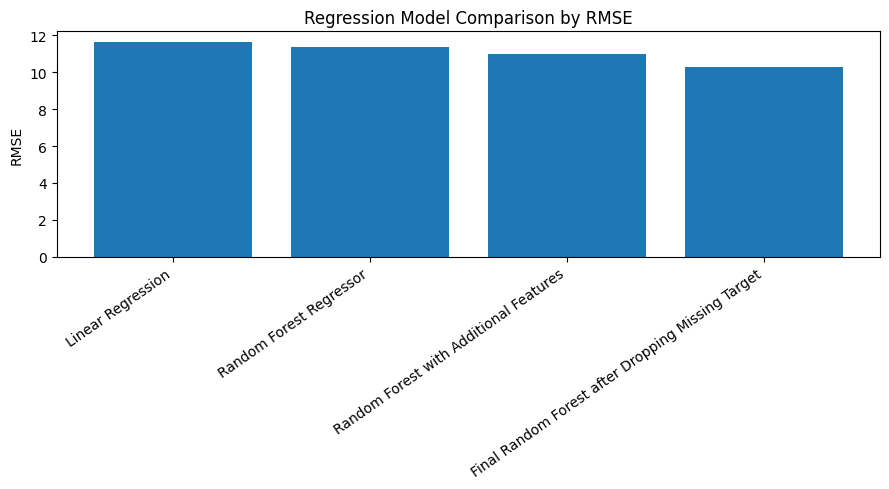

In [2]:
# Visualize RMSE comparison
# Lower RMSE means better prediction performance.

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.bar(regression_results["Model"], regression_results["RMSE"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("RMSE")
plt.title("Regression Model Comparison by RMSE")
plt.tight_layout()
plt.show()


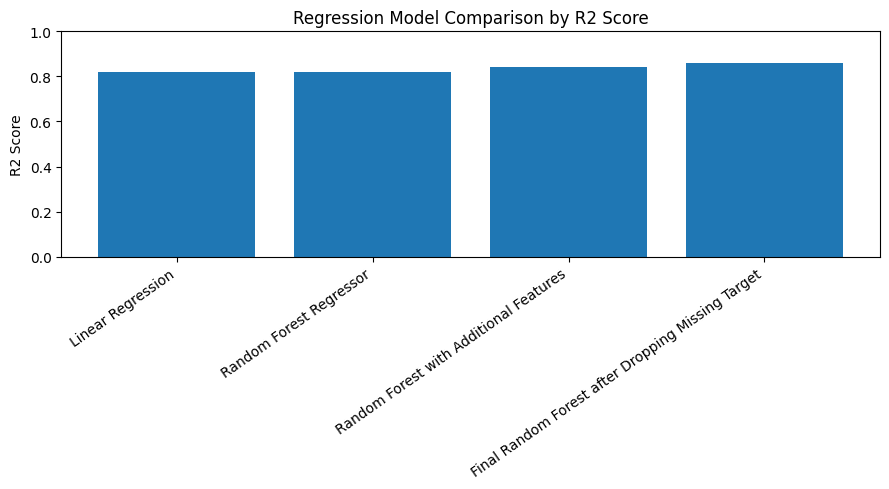

In [3]:
# Visualize R2 score comparison
# Higher R2 score means the model explains more variance in productivity_score.

plt.figure(figsize=(9, 5))
plt.bar(regression_results["Model"], regression_results["R2 Score"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("R2 Score")
plt.title("Regression Model Comparison by R2 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 4.2 Regression Interpretation

Linear Regression achieved an RMSE of **11.64** and an R² score of **0.82**.  
This means that the model explained about 82% of the variation in `productivity_score`. However, Linear Regression assumes a linear relationship, so it may not fully capture more complex patterns in the data.

Random Forest Regressor slightly improved the result by reducing RMSE from **11.64** to **11.38**. This suggests that a non-linear model can represent the relationship between features and productivity score better than a simple linear model.

After adding more features, Random Forest improved again, with RMSE decreasing to **10.99** and R² increasing to **0.84**. This means that productivity is affected by multiple factors, not only social media usage.

The best result was achieved by the final Random Forest model after dropping missing target values. This model achieved an RMSE of **10.31** and an R² score of **0.86**. Since the target variable is what the model must predict, dropping missing target rows is more appropriate than replacing target values with the mean.

**Conclusion for regression:**  
The final Random Forest model is the most suitable regression model because it has the lowest RMSE and the highest R² score.


# 5. Classification Result Analysis

## 5.1 Objective

The classification task predicts `addiction_level` as one of three classes:

- `Low`
- `Medium`
- `High`

The models were evaluated using:

- **Accuracy**: Overall percentage of correct predictions.
- **Confusion Matrix**: Shows which classes were correctly or incorrectly predicted.


In [4]:
# Classification model comparison table

classification_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [1.00, 1.00, 0.88],
    "Interpretation": [
        "Correctly classified all test samples",
        "Correctly classified all test samples and is more stable",
        "Some errors occurred near class boundaries"
    ]
})

classification_results


,Model,Accuracy,Interpretation
0,Decision Tree,1.00,Correctly classified all test samples
1,Random Forest,1.00,Correctly classified all test samples and is m...
2,KNN,0.88,Some errors occurred near class boundaries


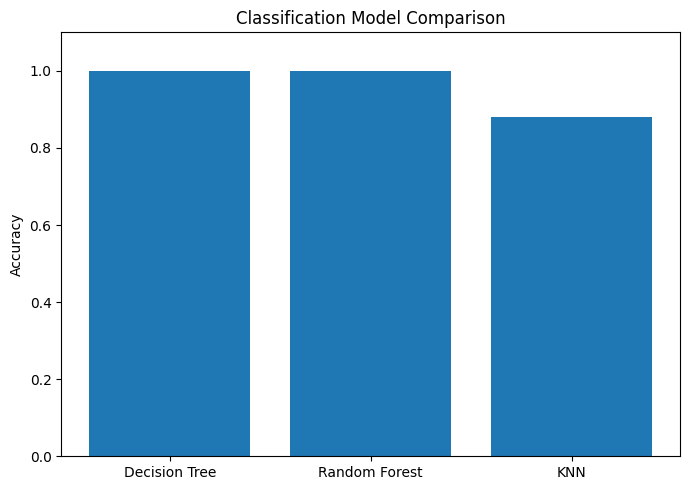

In [5]:
# Visualize classification accuracy comparison
# Higher accuracy means better classification performance.

plt.figure(figsize=(7, 5))
plt.bar(classification_results["Model"], classification_results["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Classification Model Comparison")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


## 5.2 Confusion Matrix Summary

Decision Tree and Random Forest both achieved perfect classification on the test set.

For both Decision Tree and Random Forest:

| Actual Class | Correct Predictions |
|---|---:|
| High | 317 |
| Low | 162 |
| Medium | 521 |

KNN achieved lower accuracy because it had some misclassifications, especially between neighboring classes.

KNN confusion matrix summary:

| Actual Class | Predicted High | Predicted Low | Predicted Medium |
|---|---:|---:|---:|
| High | 291 | 0 | 26 |
| Low | 0 | 121 | 41 |
| Medium | 30 | 23 | 468 |

This shows that KNN mainly confused `Medium` with `High` or `Low`.


## 5.3 Classification Interpretation

Decision Tree and Random Forest both achieved an accuracy of **1.00**, meaning that all test samples were correctly classified.

KNN achieved an accuracy of **0.88**. This is still a good result, but it is lower than Decision Tree and Random Forest. KNN is a distance-based model, so it can make mistakes when samples are located near the boundary between classes.

Although Decision Tree also achieved perfect accuracy, Random Forest is a better final choice because it combines multiple decision trees. This makes it more stable and reduces the risk of relying too much on a single tree structure.

**Conclusion for classification:**  
Random Forest is the most suitable classification model because it achieved perfect accuracy and is more stable than a single Decision Tree.

In addition to the train/test split evaluation, the classification models were also evaluated using 5-fold Stratified K-Fold Cross Validation. StratifiedKFold was used to preserve the class ratio in each fold, and cross_val_score was used to calculate the cross-validation accuracy for each model. This satisfies the project requirement that classification models must be tested using k-fold cross validation.


# 6. Feature Importance Interpretation

The feature importance result from the classification model showed that the most important features were:

1. `social_media_hours`
2. `daily_screen_time`
3. `focus_score`
4. `study_hours`
5. `notifications_per_day`
6. `sleep_hours`
7. `age`

The most important variable was `social_media_hours`. This means that daily social media usage time had the strongest effect on predicting addiction level.

This result is consistent with the EDA findings. In the EDA, higher addiction levels were related to higher social media usage and longer screen time.


In [6]:
# Feature importance ranking table
# Exact numerical importance values may depend on the model output.
# This table summarizes the ranking used for interpretation.

feature_importance_ranking = pd.DataFrame({
    "Rank": [1, 2, 3, 4, 5, 6, 7],
    "Feature": [
        "social_media_hours",
        "daily_screen_time",
        "focus_score",
        "study_hours",
        "notifications_per_day",
        "sleep_hours",
        "age"
    ],
    "Interpretation": [
        "Most important feature for addiction level",
        "Important digital usage feature",
        "Related to productivity and addiction level",
        "Related to productivity behavior",
        "May interrupt focus",
        "Lifestyle factor",
        "Lowest importance among listed features"
    ]
})

feature_importance_ranking


,Rank,Feature,Interpretation
0,1,social_media_hours,Most important feature for addiction level
1,2,daily_screen_time,Important digital usage feature
2,3,focus_score,Related to productivity and addiction level
3,4,study_hours,Related to productivity behavior
4,5,notifications_per_day,May interrupt focus
5,6,sleep_hours,Lifestyle factor
6,7,age,Lowest importance among listed features


# 7. Overall Interpretation

The regression and classification results support the same overall conclusion.

In the regression task, social media usage and screen time were related to `productivity_score`. The final Random Forest model predicted productivity score with the best performance.

In the classification task, `social_media_hours` and `daily_screen_time` were the most important features for predicting `addiction_level`.

Therefore, the results suggest that higher social media usage is related to:

- Lower productivity score
- Higher addiction level

On the other hand, productive behaviors such as higher `study_hours` and better `focus_score` are related to higher productivity.


# 8. Limitations

The models showed high performance, especially in classification. However, there are some limitations.

- The classification accuracy of 1.00 may indicate that the dataset has very clear class separation.
- If the dataset is simulated or strongly rule-based, the same performance may not appear on real-world data.
- Further testing with additional real-world datasets would be needed to verify generalization performance.

These limitations should be briefly mentioned in the final write-up or presentation.


# 9. Final Write-up Draft

## Regression Analysis

The regression task aimed to predict `productivity_score` using behavioral and lifestyle features. Several regression models were compared using RMSE and R² score.

Linear Regression achieved an RMSE of 11.64 and an R² score of 0.82. Although this model showed reasonable explanatory power, it had limitations because it assumed a linear relationship between the input features and `productivity_score`.

The Random Forest Regressor improved the prediction performance by reducing RMSE. After adding more features and removing rows with missing target values, the final Random Forest model achieved the best performance with an RMSE of 10.31 and an R² score of 0.86.

Therefore, Random Forest was selected as the most suitable regression model for predicting `productivity_score`.

## Classification Analysis

The classification task aimed to predict `addiction_level` as Low, Medium, or High. Decision Tree, Random Forest, and KNN models were compared using accuracy and confusion matrix.

Decision Tree and Random Forest both achieved an accuracy of 1.00, while KNN achieved an accuracy of 0.88. Although Decision Tree also showed perfect accuracy, Random Forest was considered more stable because it combines multiple decision trees and reduces the risk of overfitting.

Feature importance analysis showed that `social_media_hours` and `daily_screen_time` were the most important variables for predicting `addiction_level`.

## Overall Conclusion

Overall, the regression and classification results suggest that higher social media usage is associated with lower productivity and higher addiction level. Random Forest showed the best overall performance in both prediction tasks.
